# EDA: House Prices (Ames Housing)

Анализ исходных `train.csv` (1 460 домов) и `test.csv` (1 459 домов). Целевая переменная `SalePrice` доступна только в train. Все связи с ценой ниже описательные и не доказывают причинность. При обучении моделей статистики заполнения пропусков и кодирования категорий нужно оценивать только на обучающей части каждого CV-фолда.

Ноутбук можно запускать как из корня репозитория, так и из папки `notebooks/house_price`. Источник значений категорий: `data/house_price/raw/data_description.txt`.

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
root = Path.cwd()
while not (root / "data/house_price/raw/train.csv").exists() and root != root.parent:
    root = root.parent
data_dir = root / "data/house_price/raw"
train = pd.read_csv(data_dir / "train.csv", keep_default_na=False, na_values=["NA", ""])
test = pd.read_csv(data_dir / "test.csv", keep_default_na=False, na_values=["NA", ""])
print(f"Train: {train.shape}; test: {test.shape}")
print(f"Уникальные Id: train={train.Id.is_unique}, test={test.Id.is_unique}")
print(f"Полные дубликаты: train={train.duplicated().sum()}, test={test.duplicated().sum()}")
print(f"Цель в train: {'SalePrice' in train}; цель в test: {'SalePrice' in test}")

Train: (1460, 81); test: (1459, 80)
Уникальные Id: train=True, test=True
Полные дубликаты: train=0, test=0
Цель в train: True; цель в test: False


## 1. Цена продажи

Медиана — **163 000**, среднее — **180 921**, 99-й процентиль — **442 567**, максимум — **755 000**. Асимметрия `SalePrice` равна **1,883**, после `log1p` — **0,121**. Логарифм делает распределение ближе к симметричному; это полезный кандидат для моделирования и анализа относительных ошибок. Обратное преобразование прогноза требует `expm1`.

count      1460.0
mean     180921.2
std       79442.5
min       34900.0
1%        61816.0
25%      129975.0
50%      163000.0
75%      214000.0
95%      326100.0
99%      442567.0
max      755000.0
Асимметрия: цена=1.883, log1p=0.121


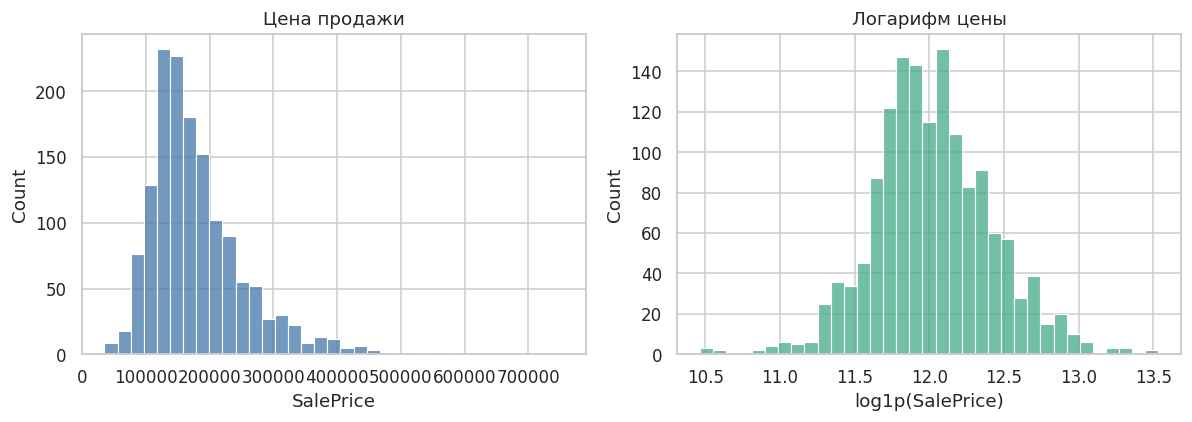

In [2]:
print(train.SalePrice.describe(percentiles=[.01, .25, .5, .75, .95, .99]).round(1).to_string())
print(f"Асимметрия: цена={train.SalePrice.skew():.3f}, log1p={np.log1p(train.SalePrice).skew():.3f}")
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(train.SalePrice, bins=35, ax=axes[0], color="#4477aa")
sns.histplot(np.log1p(train.SalePrice), bins=35, ax=axes[1], color="#44aa88")
axes[0].set(title="Цена продажи", xlabel="SalePrice")
axes[1].set(title="Логарифм цены", xlabel="log1p(SalePrice)")
plt.tight_layout(); plt.show()

## 2. Пропуски и смысл `NA`

Наибольшие доли пропусков в train: `PoolQC` **99,5%**, `MiscFeature` **96,3%**, `Alley` **93,8%**, `Fence` **80,8%**, `FireplaceQu` **47,3%**, `LotFrontage` **17,7%**. В словаре Ames `NA` для бассейна, переулка, забора, камина, гаража и подвала может означать отсутствие объекта. Категория `MasVnrType="None"` означает отсутствие облицовки; при стандартном чтении pandas ошибочно превращает её в пропуск. Здесь она сохранена, и действительно неизвестных значений этого поля **8** в train. Однако не каждый пропуск структурный: например, `LotFrontage` требует отдельной стратегии; в test есть единичные пропуски `MSZoning`, `KitchenQual`, `GarageCars` и других полей. Не следует просто удалять все столбцы с большой долей пропусков.

              train_n  train_pct  test_n  test_pct
PoolQC           1453       99.5  1456.0      99.8
MiscFeature      1406       96.3  1408.0      96.5
Alley            1369       93.8  1352.0      92.7
Fence            1179       80.8  1169.0      80.1
FireplaceQu       690       47.3   730.0      50.0
LotFrontage       259       17.7   227.0      15.6
GarageYrBlt        81        5.5    78.0       5.3
GarageType         81        5.5    76.0       5.2
GarageFinish       81        5.5    78.0       5.3
GarageQual         81        5.5    78.0       5.3
GarageCond         81        5.5    78.0       5.3
BsmtFinType2       38        2.6    42.0       2.9
BsmtExposure       38        2.6    44.0       3.0
BsmtQual           37        2.5    44.0       3.0
BsmtCond           37        2.5    45.0       3.1
BsmtFinType1       37        2.5    42.0       2.9
MasVnrArea          8        0.5    15.0       1.0
MasVnrType          8        0.5    16.0       1.1
Electrical          1        0.

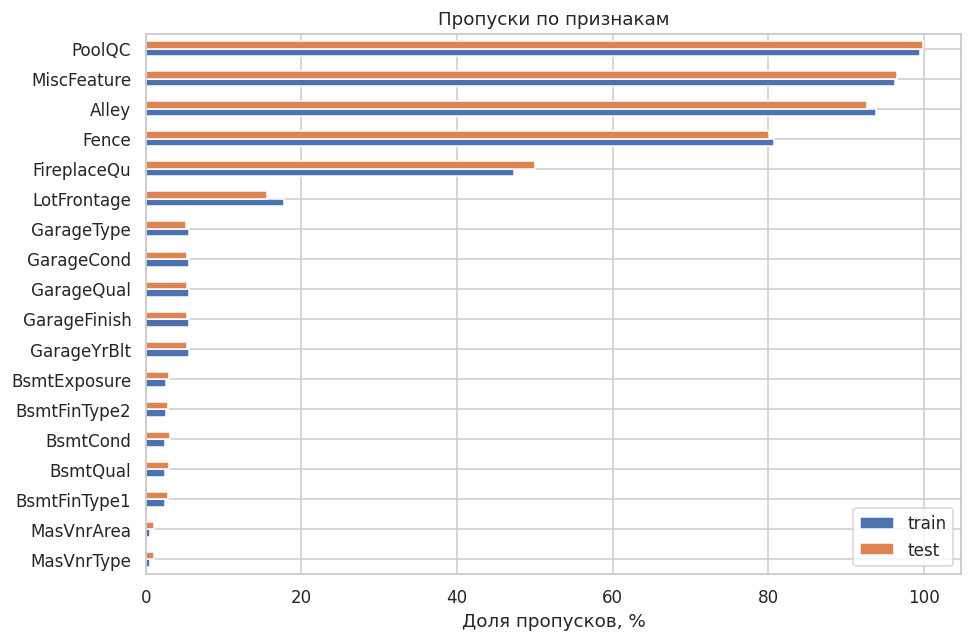

In [3]:
missing = pd.DataFrame({
    "train_n": train.isna().sum(), "train_pct": train.isna().mean() * 100,
    "test_n": test.isna().sum(), "test_pct": test.isna().mean() * 100,
}).fillna(0).sort_values("train_pct", ascending=False)
print(missing.loc[(missing.train_n > 0) | (missing.test_n > 0)].round(1).to_string())
fig, ax = plt.subplots(figsize=(9, 6))
missing.head(18)[["train_pct", "test_pct"]].sort_values("train_pct").plot.barh(ax=ax)
ax.set(xlabel="Доля пропусков, %", ylabel="", title="Пропуски по признакам")
ax.legend(["train", "test"])
plt.tight_layout(); plt.show()

## 3. Числовые признаки и цена

Наибольшая линейная корреляция с `SalePrice` у `OverallQual` (**0,791**), `GrLivArea` (**0,709**), `GarageCars` (**0,640**), `GarageArea` (**0,623**) и `TotalBsmtSF` (**0,614**). `OverallQual` — порядковый балл; его корреляция описывает тренд, но расстояния между уровнями не обязательно равны. Площади, размер гаража и число комнат частично дублируют информацию, поэтому коэффициенты линейной модели следует интерпретировать осторожно.

OverallQual     0.791
GrLivArea       0.709
GarageCars      0.640
GarageArea      0.623
TotalBsmtSF     0.614
1stFlrSF        0.606
FullBath        0.561
TotRmsAbvGrd    0.534
YearBuilt       0.523
YearRemodAdd    0.507
GarageYrBlt     0.486
MasVnrArea      0.477
Fireplaces      0.467
BsmtFinSF1      0.386
LotFrontage     0.352


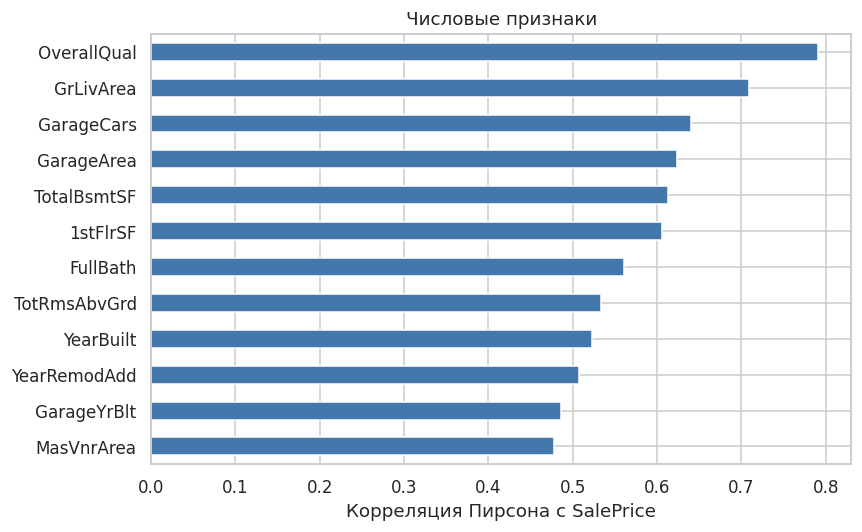

In [4]:
numeric = train.select_dtypes(include="number").drop(columns=["Id", "SalePrice"])
correlations = numeric.corrwith(train.SalePrice).dropna().sort_values(ascending=False)
print(correlations.head(15).round(3).to_string())
fig, ax = plt.subplots(figsize=(8, 5))
correlations.head(12).sort_values().plot.barh(ax=ax, color="#4477aa")
ax.set(xlabel="Корреляция Пирсона с SalePrice", ylabel="", title="Числовые признаки")
plt.tight_layout(); plt.show()

## 4. Площадь и необычные наблюдения

По правилу 1,5 × IQR для `GrLivArea` верхняя граница **2 747,6**, выше неё **31** дом. Особенно заметны дома `Id=524` (4 676 кв. футов, цена 184 750) и `Id=1299` (5 642, цена 160 000). Это кандидаты для проверки чувствительности модели, а не доказанные ошибки; удаление строк по цене до валидации может исказить оценку качества.

GrLivArea: граница IQR=2747.6; выше границы=31
  Id  GrLivArea  SalePrice
 524       4676     184750
 692       4316     755000
1183       4476     745000
1299       5642     160000


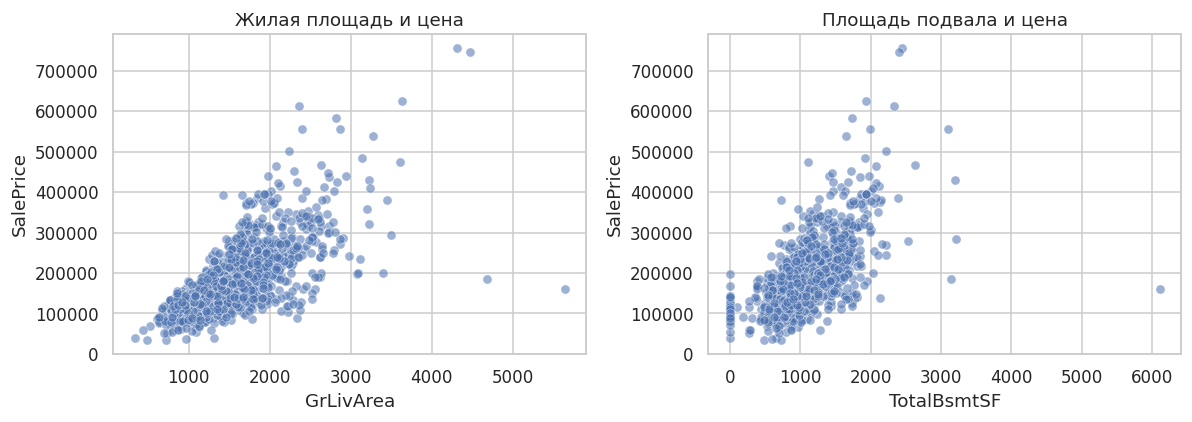

In [5]:
q1, q3 = train.GrLivArea.quantile([.25, .75])
upper = q3 + 1.5 * (q3 - q1)
print(f"GrLivArea: граница IQR={upper:.1f}; выше границы={(train.GrLivArea > upper).sum()}")
print(train.loc[train.GrLivArea > 4000, ["Id", "GrLivArea", "SalePrice"]].to_string(index=False))
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.scatterplot(data=train, x="GrLivArea", y="SalePrice", alpha=.55, ax=axes[0])
sns.scatterplot(data=train, x="TotalBsmtSF", y="SalePrice", alpha=.55, ax=axes[1])
for ax in axes:
    ax.ticklabel_format(axis="y", style="plain")
axes[0].set(title="Жилая площадь и цена")
axes[1].set(title="Площадь подвала и цена")
plt.tight_layout(); plt.show()

## 5. Качество, гараж и район

Медиана цены при `OverallQual=5` — **133 000** (397 домов), при `7` — **200 141** (319), при `9` — **345 000** (43). У домов без места в гараже медиана **100 000** (81), с двумя местами — **177 750** (824), с тремя — **295 000** (181). Районы различаются по цене: например, `NridgHt` — медиана **315 000** (77), `NoRidge` — **301 500** (41). Редкие районы и категории дают менее устойчивые оценки.


OverallQual:
               n    median
OverallQual               
10            18  432390.0
9             43  345000.0
8            168  269750.0
7            319  200141.0
6            374  160000.0
5            397  133000.0
4            116  108000.0
3             20   86250.0
2              3   60000.0
1              2   50150.0

GarageCars:
              n    median
GarageCars               
3           181  295000.0
4             5  200000.0
2           824  177750.0
1           369  128000.0
0            81  100000.0

Neighborhood:
                n    median
Neighborhood               
NridgHt        77  315000.0
NoRidge        41  301500.0
StoneBr        25  278000.0
Timber         38  228475.0
Somerst        86  225500.0
Veenker        11  218000.0
Crawfor        51  200624.0
ClearCr        28  200250.0
CollgCr       150  197200.0
Blmngtn        17  191000.0
NWAmes         73  182900.0
Gilbert        79  181000.0
SawyerW        59  179900.0
Mitchel        49  153500.0
NPkV

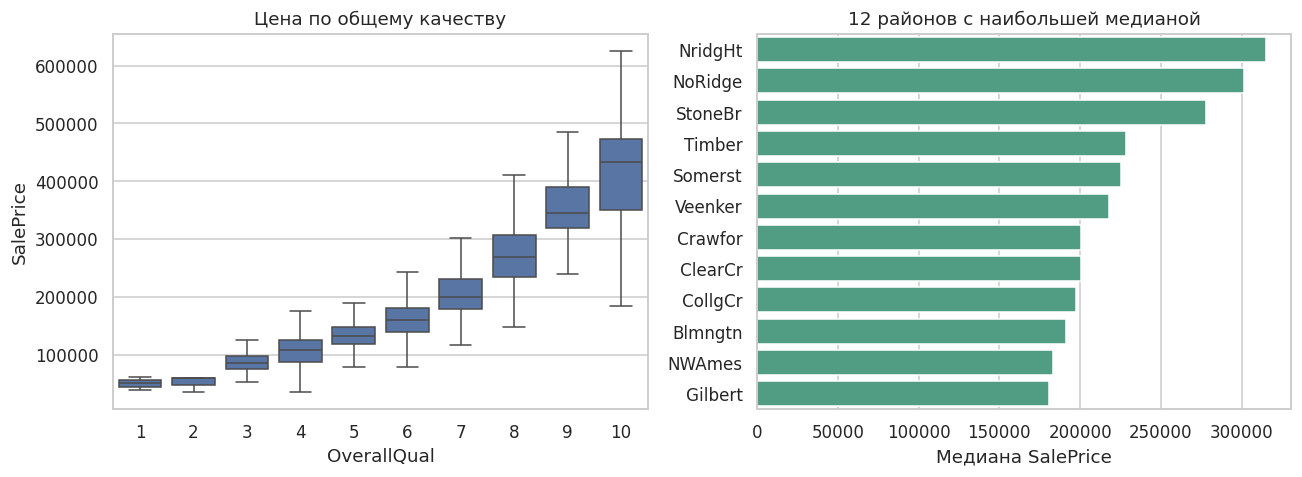

In [6]:
for col in ["OverallQual", "GarageCars", "Neighborhood"]:
    print(f"\n{col}:")
    print(train.groupby(col, dropna=False).SalePrice.agg(n="size", median="median").sort_values("median", ascending=False).round(0).to_string())
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.boxplot(data=train, x="OverallQual", y="SalePrice", showfliers=False, ax=axes[0])
neighborhood = train.groupby("Neighborhood").SalePrice.median().sort_values(ascending=False)
top = neighborhood.head(12)
sns.barplot(x=top.values, y=top.index, ax=axes[1], color="#44aa88")
axes[0].set(title="Цена по общему качеству", ylabel="SalePrice")
axes[1].set(title="12 районов с наибольшей медианой", xlabel="Медиана SalePrice", ylabel="")
plt.tight_layout(); plt.show()

## 6. Train и test

Распределения ключевых признаков близки по центральным значениям: медиана `GrLivArea` — **1 464** в train против **1 432** в test; `OverallQual` — **6** в обеих выборках; `YearBuilt` — **1973** в обеих. Это не гарантирует одинаковое качество на скрытой оценке. В test имеются дополнительные пропуски, поэтому вся предобработка должна уметь обрабатывать отсутствующие значения и категории, не виденные при обучении.

             train_median  test_median
GrLivArea          1464.0       1432.0
LotArea            9478.5       9399.0
OverallQual           6.0          6.0
YearBuilt          1973.0       1973.0
GarageCars            2.0          2.0
Категории test, отсутствующие в train: {}


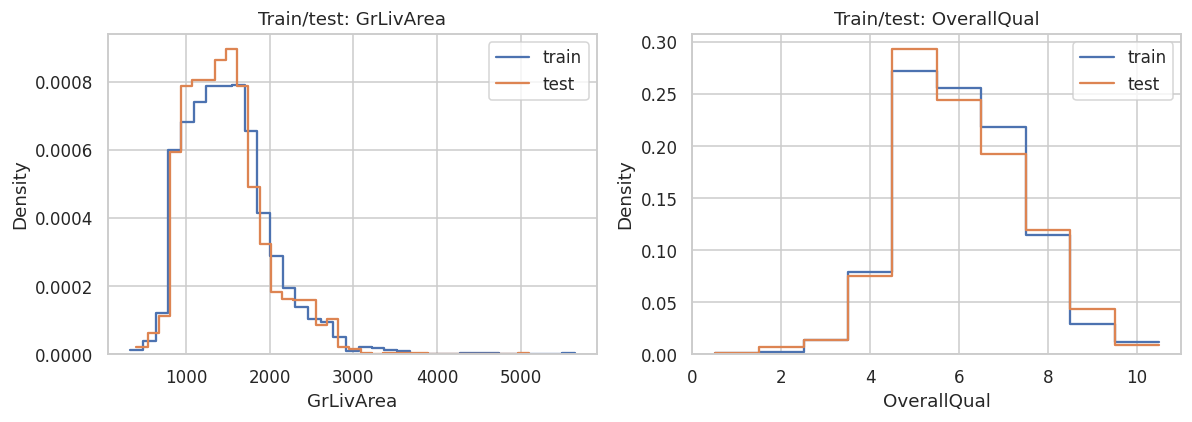

In [7]:
comparison = pd.DataFrame({
    "train_median": train[["GrLivArea", "LotArea", "OverallQual", "YearBuilt", "GarageCars"]].median(),
    "test_median": test[["GrLivArea", "LotArea", "OverallQual", "YearBuilt", "GarageCars"]].median(),
})
print(comparison.to_string())
unseen = {col: sorted(set(test[col].dropna()) - set(train[col].dropna()))
          for col in train.select_dtypes(include="object").columns}
print("Категории test, отсутствующие в train:", {k: v for k, v in unseen.items() if v})
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, col, bins in zip(axes, ["GrLivArea", "OverallQual"], [35, np.arange(.5, 11.5)]):
    sns.histplot(train[col], bins=bins, stat="density", element="step", fill=False, ax=ax, label="train")
    sns.histplot(test[col], bins=bins, stat="density", element="step", fill=False, ax=ax, label="test")
    ax.set(title=f"Train/test: {col}")
    ax.legend()
plt.tight_layout(); plt.show()

## 7. Feature engineering: признаки из известных полей

Ниже одна функция для train и test; она не использует `SalePrice` и не обучает параметры на данных. Создаются возраст дома и давность ремонта на момент продажи, суммарная площадь надземной части и подвала, число ванных с половинной ванной весом 0,5, площадь крылец и террас, признаки наличия гаража/подвала и взаимодействие качества с жилой площадью. `TotalAreaSF` объединяет общую площадь подвала, в том числе незавершённую, поэтому не называется «жилой» или «отделанной». Пропуски в исходных числах сохраняются, а индикаторы наличия остаются неизвестными, если исходное поле отсутствует.

В данных есть отрицательные значения возраста на момент продажи: **1** случай `YearsSinceRemodel` в train, **1** `HouseAgeAtSale` и **2** `YearsSinceRemodel` в test. Они оставлены видимыми для проверки качества данных; исправление требует отдельного решения.

In [8]:
def make_eda_features(frame: pd.DataFrame) -> pd.DataFrame:
    result = frame.copy()
    result["HouseAgeAtSale"] = result["YrSold"] - result["YearBuilt"]
    result["YearsSinceRemodel"] = result["YrSold"] - result["YearRemodAdd"]
    result["TotalAreaSF"] = result[["GrLivArea", "TotalBsmtSF"]].sum(axis=1, min_count=2)
    result["TotalBathrooms"] = (
        result["FullBath"] + 0.5 * result["HalfBath"]
        + result["BsmtFullBath"] + 0.5 * result["BsmtHalfBath"]
    )
    outdoor_columns = ["WoodDeckSF", "OpenPorchSF", "EnclosedPorch", "3SsnPorch", "ScreenPorch"]
    result["OutdoorAreaSF"] = result[outdoor_columns].sum(axis=1, min_count=len(outdoor_columns))
    for new_col, original in [("HasGarage", "GarageCars"), ("HasBasement", "TotalBsmtSF")]:
        values = result[original]
        result[new_col] = values.gt(0).where(values.notna(), pd.NA).astype("Int64")
    result["QualityXLivingArea"] = result["OverallQual"] * result["GrLivArea"]
    return result

train_fe = make_eda_features(train)
test_fe = make_eda_features(test)
new_features = ["HouseAgeAtSale", "YearsSinceRemodel", "TotalAreaSF", "TotalBathrooms",
                "OutdoorAreaSF", "HasGarage", "HasBasement", "QualityXLivingArea"]
print("Новые признаки:", ", ".join(new_features))
print("Пропуски в новых признаках (train/test):")
print(pd.DataFrame({"train": train_fe[new_features].isna().sum(),
                    "test": test_fe[new_features].isna().sum()}).to_string())
for name, frame in [("train", train_fe), ("test", test_fe)]:
    print(f"{name}: отрицательный возраст дома={(frame.HouseAgeAtSale < 0).sum()}, "
          f"отрицательная давность ремонта={(frame.YearsSinceRemodel < 0).sum()}")
assert len(train_fe) == len(train) and len(test_fe) == len(test)
assert "SalePrice" not in test_fe
assert train_fe[new_features].notna().all(axis=1).sum() <= len(train_fe)

Новые признаки: HouseAgeAtSale, YearsSinceRemodel, TotalAreaSF, TotalBathrooms, OutdoorAreaSF, HasGarage, HasBasement, QualityXLivingArea
Пропуски в новых признаках (train/test):
                    train  test
HouseAgeAtSale          0     0
YearsSinceRemodel       0     0
TotalAreaSF             0     1
TotalBathrooms          0     2
OutdoorAreaSF           0     0
HasGarage               0     1
HasBasement             0     1
QualityXLivingArea      0     0
train: отрицательный возраст дома=0, отрицательная давность ремонта=1
test: отрицательный возраст дома=1, отрицательная давность ремонта=2


### Связь новых признаков с ценой

Следующие таблицы и графики показывают только описательные связи в train. Производные признаки сильно связаны с исходными: высокая корреляция с ценой не означает прирост качества модели. Для бинарных индикаторов удобнее сравнивать медианы и размер групп; для площадей и возраста — смотреть форму связи и выбросы. Взаимодействие `QualityXLivingArea` особенно склонно дублировать исходные `OverallQual` и `GrLivArea`.

Корреляция с SalePrice:
QualityXLivingArea    0.832
TotalAreaSF           0.779
TotalBathrooms        0.632
OutdoorAreaSF         0.391
YearsSinceRemodel    -0.509
HouseAgeAtSale       -0.523

HasGarage:
              n    median
HasGarage                
0            81  100000.0
1          1379  167500.0

HasBasement:
                n    median
HasBasement                
0              37  101800.0
1            1423  165000.0


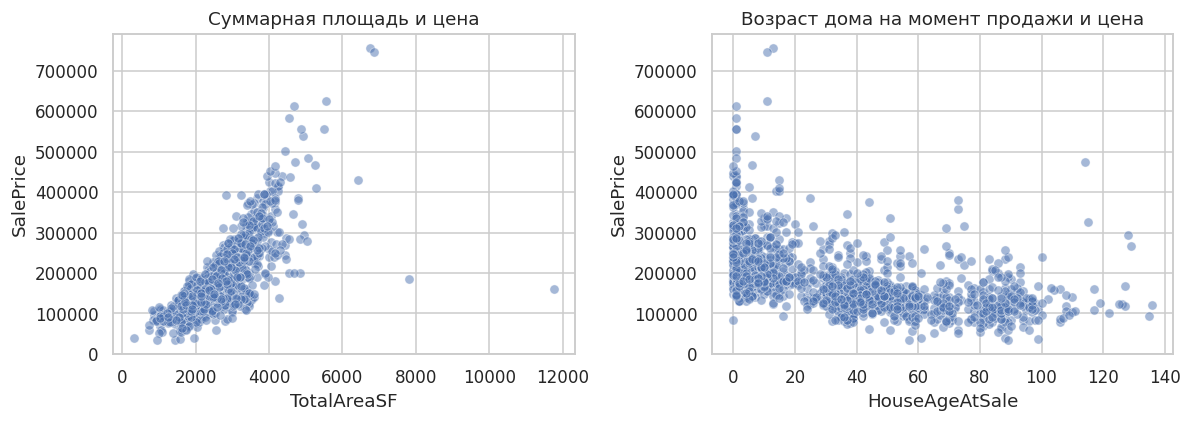

In [9]:
continuous_features = ["HouseAgeAtSale", "YearsSinceRemodel", "TotalAreaSF",
                       "TotalBathrooms", "OutdoorAreaSF", "QualityXLivingArea"]
print("Корреляция с SalePrice:")
print(train_fe[continuous_features].corrwith(train_fe.SalePrice).sort_values(ascending=False).round(3).to_string())
for col in ["HasGarage", "HasBasement"]:
    print(f"\n{col}:")
    print(train_fe.groupby(col, dropna=False).SalePrice.agg(n="size", median="median").to_string())
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.scatterplot(data=train_fe, x="TotalAreaSF", y="SalePrice", alpha=.5, ax=axes[0])
sns.scatterplot(data=train_fe, x="HouseAgeAtSale", y="SalePrice", alpha=.5, ax=axes[1])
axes[0].set(title="Суммарная площадь и цена")
axes[1].set(title="Возраст дома на момент продажи и цена")
plt.tight_layout(); plt.show()

## Выводы для следующего этапа

1. Проверить модель с `log1p(SalePrice)` и сравнить её с моделью на исходной шкале по выбранной CV-метрике.
2. Разделить структурное отсутствие (`No garage`, `No basement` и т. п.) и неизвестные значения. Числовые пропуски вроде `LotFrontage` заполнять внутри CV-пайплайна.
3. Начать с `OverallQual`, жилой площади, подвала, гаража, года постройки и района. Проверить добавление созданных здесь признаков по CV, особенно возраста, общей площади и числа ванных. Корреляции и графики не измеряют прирост качества.
4. Отдельно проверить устойчивость к крупным домам с низкой ценой. Не исключать их автоматически.
5. Разобраться с отрицательным возрастом в трёх строках, прежде чем использовать такие признаки в модели.

Для регрессии нужен отдельный протокол валидации; здесь модель не обучалась и результат на test не оценивался.